# Skin Lesion Classification — 5-Class FAST Version (Structured)

A lighter, quicker version of the full 9-class pipeline: same three tables,
but restricted to **5 classes** and **fewer epochs** so a full run finishes
much faster (good for a first pass / sanity check before the full run).

This version keeps the exact same logic as the original notebook, but
organizes it into small, single-purpose classes/functions grouped by
responsibility (config, data, models, training, feature extraction,
efficiency benchmarking), so each stage is easier to read, test, and reuse.

1. **Table 1** — Transfer learning models (AlexNet → EfficientNet-B0)
2. **Table 2** — Classical classifiers on deep features
3. **Table 3** — Computational efficiency comparison

Dataset: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
(download it yourself, unzip, upload to Drive — no Kaggle API needed here).

Run cells top to bottom. GPU runtime recommended (Runtime → Change runtime type → T4 GPU).

## 1. Install dependencies

In [3]:
!pip install -q thop xgboost


## 2. Dataset — mount Drive and set the path

Download the dataset yourself from Kaggle:
https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic

Unzip it and upload the folder to your Google Drive (or upload the zip and
unzip it directly in Colab — see the commented option below). Then set
`DATA_ROOT` in the next cell to wherever the `Train`/`Test` subfolders end up.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import kagglehub
import os

# Download the dataset using kagglehub
# This will download and extract the dataset to a temporary directory
# and return the path to the extracted dataset.
dataset_path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

# Set DATA_ROOT to the path where the dataset was extracted.
# The output from the previous run indicates the main content is in a subfolder:
# Contents of DATA_ROOT: ['Skin cancer ISIC The International Skin Imaging Collaboration']
DATA_ROOT = os.path.join(dataset_path, "Skin cancer ISIC The International Skin Imaging Collaboration")

print("Contents of DATA_ROOT:", os.listdir(DATA_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Contents of DATA_ROOT: ['Test', 'Train']


## 3. Config — a single dataclass holds every hyperparameter

Edit values here if needed; everything downstream reads from this one object instead of scattered globals.

In [5]:
import os
from dataclasses import dataclass, field
from typing import List

import torch


@dataclass
class Config:
    """All paths, hyperparameters, and model choices in one place."""

    data_root: str
    output_dir: str = "./results"

    # Chosen for a clinically meaningful mix of malignant + benign + decent sample counts
    class_subset: List[str] = field(default_factory=lambda: [
        "nevus",
        "melanoma",
        "basal cell carcinoma",
        "pigmented benign keratosis",
        "squamous cell carcinoma",
    ])

    val_fraction_of_train: float = 0.15
    random_seed: int = 42

    image_size: int = 224
    batch_size: int = 32
    feature_extract_epochs: int = 2   # reduced from 5 for speed
    fine_tune_epochs: int = 6         # reduced from 20 for speed
    learning_rate: float = 1e-4
    num_workers: int = 2
    num_timing_runs: int = 50

    cnn_models: List[str] = field(default_factory=lambda: [
        "alexnet", "vgg16", "vgg19", "resnet18",
        "resnet50", "resnet101", "densenet121", "efficientnet_b0",
    ])

    @property
    def train_dir(self) -> str:
        return os.path.join(self.data_root, "Train")

    @property
    def test_dir(self) -> str:
        return os.path.join(self.data_root, "Test")

    @property
    def device(self) -> torch.device:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def checkpoint_path(self, model_name: str) -> str:
        return os.path.join(self.output_dir, f"{model_name}_best.pt")

    def ensure_output_dir(self) -> None:
        os.makedirs(self.output_dir, exist_ok=True)


cfg = Config(data_root=DATA_ROOT)
cfg.ensure_output_dir()
DEVICE = cfg.device

print("Train classes found:", os.listdir(cfg.train_dir))
print("Test classes found:", os.listdir(cfg.test_dir))
print("Using device:", DEVICE)
print("Using class subset:", cfg.class_subset)


Train classes found: ['pigmented benign keratosis', 'melanoma', 'vascular lesion', 'actinic keratosis', 'squamous cell carcinoma', 'basal cell carcinoma', 'seborrheic keratosis', 'dermatofibroma', 'nevus']
Test classes found: ['pigmented benign keratosis', 'melanoma', 'vascular lesion', 'actinic keratosis', 'squamous cell carcinoma', 'basal cell carcinoma', 'seborrheic keratosis', 'dermatofibroma', 'nevus']
Using device: cuda
Using class subset: ['nevus', 'melanoma', 'basal cell carcinoma', 'pigmented benign keratosis', 'squamous cell carcinoma']


## 4. Dataset loading — filtered to the 5-class subset

Unlike the full pipeline (which uses every subfolder via `ImageFolder`), this
version only scans the 5 folders listed in `cfg.class_subset`.

Grouped into a single `SkinLesionData` class: scanning, splitting, and
`Dataset`/`DataLoader` construction are all methods on one object instead of
loose module-level functions.

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets.folder import default_loader
import torchvision.transforms as T

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")


class FilteredImageDataset(Dataset):
    """Dataset over a pre-scanned (path, label) samples list, restricted to
    the configured class subset, with a configurable transform."""

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = default_loader(path)
        if self.transform:
            image = self.transform(image)
        return image, label


class SkinLesionData:
    """Scans the filtered class folders, splits train/val, and builds the
    three DataLoaders. All dataset-related logic lives here."""

    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.classes: List[str] = []
        self.class_to_idx: dict = {}
        self.train_ds = self.val_ds = self.test_ds = None
        self.train_loader = self.val_loader = self.test_loader = None

    @staticmethod
    def _scan_filtered_samples(root, allowed_classes):
        """Like torchvision.datasets.ImageFolder, but only scans the given
        subfolders instead of every subfolder under root."""
        classes = sorted(allowed_classes)
        class_to_idx = {c: i for i, c in enumerate(classes)}
        samples = []
        for c in classes:
            class_dir = os.path.join(root, c)
            if not os.path.isdir(class_dir):
                raise FileNotFoundError(f"Expected class folder not found: {class_dir}")
            for fname in sorted(os.listdir(class_dir)):
                if fname.lower().endswith(IMG_EXTENSIONS):
                    samples.append((os.path.join(class_dir, fname), class_to_idx[c]))
        return samples, classes, class_to_idx

    @staticmethod
    def _get_transforms(image_size: int, train: bool):
        normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        if train:
            return T.Compose([
                T.Resize((image_size, image_size)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
                T.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=0.2),
                T.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
                T.ToTensor(),
                normalize,
            ])
        return T.Compose([T.Resize((image_size, image_size)), T.ToTensor(), normalize])

    def load(self) -> "SkinLesionData":
        cfg = self.cfg
        train_samples_all, self.classes, self.class_to_idx = self._scan_filtered_samples(
            cfg.train_dir, cfg.class_subset
        )
        test_samples, _, _ = self._scan_filtered_samples(cfg.test_dir, cfg.class_subset)

        labels = np.array([lbl for _, lbl in train_samples_all])
        indices = np.arange(len(train_samples_all))
        train_idx, val_idx = train_test_split(
            indices, test_size=cfg.val_fraction_of_train, stratify=labels,
            random_state=cfg.random_seed,
        )
        train_samples = [train_samples_all[i] for i in train_idx]
        val_samples = [train_samples_all[i] for i in val_idx]

        self.train_ds = FilteredImageDataset(train_samples, self._get_transforms(cfg.image_size, train=True))
        self.val_ds = FilteredImageDataset(val_samples, self._get_transforms(cfg.image_size, train=False))
        self.test_ds = FilteredImageDataset(test_samples, self._get_transforms(cfg.image_size, train=False))

        self.train_loader = DataLoader(self.train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
        self.val_loader = DataLoader(self.val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
        self.test_loader = DataLoader(self.test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
        return self

    def unshuffled_train_loader(self) -> DataLoader:
        """Used by feature extraction, where sample order must be stable."""
        return DataLoader(self.train_ds, batch_size=self.cfg.batch_size, shuffle=False, num_workers=self.cfg.num_workers)


data = SkinLesionData(cfg).load()
classes = data.classes
print("Classes used (alphabetical order = label indices):", classes)
print(f"Train: {len(data.train_ds)}  Val: {len(data.val_ds)}  Test: {len(data.test_ds)}")


Classes used (alphabetical order = label indices): ['basal cell carcinoma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'squamous cell carcinoma']
Train: 1541  Val: 273  Test: 80


## 5. Model builders (8 transfer-learning architectures)

Same architecture-swapping logic, wrapped in a `ModelFactory` so building a model and freezing/unfreezing its backbone are two clearly named class methods instead of free functions.

In [7]:
import torch.nn as nn
from torchvision import models


class ModelFactory:
    """Builds any of the 8 supported architectures with a replaced classifier
    head, and toggles backbone trainability for the two-stage fine-tuning."""

    @staticmethod
    def build(name: str, num_classes: int) -> nn.Module:
        if name == "alexnet":
            m = models.alexnet(weights="IMAGENET1K_V1")
            m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
        elif name == "vgg16":
            m = models.vgg16(weights="IMAGENET1K_V1")
            m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
        elif name == "vgg19":
            m = models.vgg19(weights="IMAGENET1K_V1")
            m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
        elif name == "resnet18":
            m = models.resnet18(weights="IMAGENET1K_V1")
            m.fc = nn.Linear(m.fc.in_features, num_classes)
        elif name == "resnet50":
            m = models.resnet50(weights="IMAGENET1K_V2")
            m.fc = nn.Linear(m.fc.in_features, num_classes)
        elif name == "resnet101":
            m = models.resnet101(weights="IMAGENET1K_V2")
            m.fc = nn.Linear(m.fc.in_features, num_classes)
        elif name == "densenet121":
            m = models.densenet121(weights="IMAGENET1K_V1")
            m.classifier = nn.Linear(m.classifier.in_features, num_classes)
        elif name == "efficientnet_b0":
            m = models.efficientnet_b0(weights="IMAGENET1K_V1")
            m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        else:
            raise ValueError(f"Unknown model: {name}")
        return m

    @staticmethod
    def set_backbone_trainable(model: nn.Module, trainable: bool) -> None:
        for param in model.parameters():
            param.requires_grad = trainable
        last_layer = list(model.children())[-1]
        for param in last_layer.parameters():
            param.requires_grad = True

    @staticmethod
    def strip_classifier_head(model: nn.Module, name: str) -> nn.Module:
        """Replaces the final classifier layer with Identity so the model
        emits pooled deep features instead of class logits."""
        if name == "alexnet" or name.startswith("vgg"):
            model.classifier[6] = nn.Identity()
        elif name.startswith("resnet"):
            model.fc = nn.Identity()
        elif name == "densenet121":
            model.classifier = nn.Identity()
        elif name == "efficientnet_b0":
            model.classifier[1] = nn.Identity()
        return model


## 6. Training / evaluation loops

The warmup → fine-tune two-stage procedure, one epoch step, and metric computation are grouped into a `ModelTrainer` class bound to one `Config`/`SkinLesionData` pair, so `train_one_model` no longer depends on module-level globals.

In [8]:
import copy
import time
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


class ModelTrainer:
    """Runs the two-stage (feature-extraction warmup + full fine-tune)
    training procedure for one architecture and reports test-set metrics."""

    def __init__(self, cfg: Config, data: SkinLesionData, device: torch.device):
        self.cfg = cfg
        self.data = data
        self.device = device

    def _run_epoch(self, model, loader, criterion, optimizer=None):
        is_train = optimizer is not None
        model.train() if is_train else model.eval()
        total_loss, total_correct, total_samples = 0.0, 0, 0
        with torch.set_grad_enabled(is_train):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                if is_train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * images.size(0)
                total_correct += (outputs.argmax(1) == labels).sum().item()
                total_samples += images.size(0)
        return total_loss / total_samples, total_correct / total_samples

    @staticmethod
    def _compute_metrics(all_labels, all_preds, all_probs) -> dict:
        acc = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
        recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
        f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
        try:
            auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="weighted")
        except ValueError:
            auc = float("nan")
        return {
            "Accuracy (%)": round(acc * 100, 2),
            "Precision (%)": round(precision * 100, 2),
            "Recall (%)": round(recall * 100, 2),
            "F1-Score (%)": round(f1 * 100, 2),
            "AUC (%)": round(auc * 100, 2),
        }

    def evaluate(self, model, loader) -> dict:
        model.eval()
        all_labels, all_preds, all_probs = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                all_labels.extend(labels.numpy())
                all_preds.extend(probs.argmax(axis=1))
                all_probs.extend(probs)
        return self._compute_metrics(np.array(all_labels), np.array(all_preds), np.array(all_probs))

    def train_one_model(self, name: str, num_classes: int):
        cfg = self.cfg
        print(f"\n=== Training {name} ===")
        model = ModelFactory.build(name, num_classes).to(self.device)
        criterion = nn.CrossEntropyLoss()

        # Stage 1: feature extraction - freeze backbone, train head only
        ModelFactory.set_backbone_trainable(model, trainable=False)
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.learning_rate)
        for epoch in range(cfg.feature_extract_epochs):
            train_loss, train_acc = self._run_epoch(model, self.data.train_loader, criterion, optimizer)
            val_loss, val_acc = self._run_epoch(model, self.data.val_loader, criterion, optimizer=None)
            print(f"  [warmup {epoch+1}/{cfg.feature_extract_epochs}] train_acc={train_acc:.3f} val_acc={val_acc:.3f}")

        # Stage 2: fine-tune the whole network
        ModelFactory.set_backbone_trainable(model, trainable=True)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1 ** 0.5, patience=7, min_lr=0.5e-6
        )
        best_val_acc, best_state = 0.0, copy.deepcopy(model.state_dict())
        for epoch in range(cfg.fine_tune_epochs):
            train_loss, train_acc = self._run_epoch(model, self.data.train_loader, criterion, optimizer)
            val_loss, val_acc = self._run_epoch(model, self.data.val_loader, criterion, optimizer=None)
            scheduler.step(val_loss)
            if val_acc > best_val_acc:
                best_val_acc, best_state = val_acc, copy.deepcopy(model.state_dict())
            print(f"  [finetune {epoch+1}/{cfg.fine_tune_epochs}] train_acc={train_acc:.3f} val_acc={val_acc:.3f}")

        model.load_state_dict(best_state)
        metrics = self.evaluate(model, self.data.test_loader)
        metrics["Model"] = name
        torch.save(model.state_dict(), cfg.checkpoint_path(name))
        return metrics, model


## 7. Table 1 — Transfer Learning Models

Trains all 8 architectures in sequence. With 5 classes and reduced epochs
(2 warmup + 6 fine-tune), this should run noticeably faster than the full
9-class/20-epoch version — expect several minutes per model on a T4, not tens of minutes.

In [9]:
trainer = ModelTrainer(cfg, data, DEVICE)

table1_results = []
for name in cfg.cnn_models:
    start = time.time()
    metrics, _ = trainer.train_one_model(name, len(classes))
    metrics["Train Time (min)"] = round((time.time() - start) / 60, 1)
    table1_results.append(metrics)
    pd.DataFrame(table1_results).to_csv(os.path.join(cfg.output_dir, "table1_transfer_learning_results.csv"), index=False)

table1_df = pd.DataFrame(table1_results)
table1_df



=== Training alexnet ===
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 167MB/s]


  [warmup 1/2] train_acc=0.494 val_acc=0.575
  [warmup 2/2] train_acc=0.621 val_acc=0.612
  [finetune 1/6] train_acc=0.657 val_acc=0.670
  [finetune 2/6] train_acc=0.717 val_acc=0.678
  [finetune 3/6] train_acc=0.725 val_acc=0.678
  [finetune 4/6] train_acc=0.747 val_acc=0.670
  [finetune 5/6] train_acc=0.775 val_acc=0.722
  [finetune 6/6] train_acc=0.770 val_acc=0.696

=== Training vgg16 ===
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 170MB/s]


  [warmup 1/2] train_acc=0.426 val_acc=0.604
  [warmup 2/2] train_acc=0.553 val_acc=0.601
  [finetune 1/6] train_acc=0.537 val_acc=0.542
  [finetune 2/6] train_acc=0.650 val_acc=0.593
  [finetune 3/6] train_acc=0.687 val_acc=0.645
  [finetune 4/6] train_acc=0.750 val_acc=0.604
  [finetune 5/6] train_acc=0.750 val_acc=0.659
  [finetune 6/6] train_acc=0.766 val_acc=0.707

=== Training vgg19 ===
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


...

100%|██████████| 30.8M/30.8M [00:00<00:00, 109MB/s]


  [warmup 1/2] train_acc=0.241 val_acc=0.289
  [warmup 2/2] train_acc=0.300 val_acc=0.315
  [finetune 1/6] train_acc=0.600 val_acc=0.700
  [finetune 2/6] train_acc=0.757 val_acc=0.744
  [finetune 3/6] train_acc=0.824 val_acc=0.700
  [finetune 4/6] train_acc=0.839 val_acc=0.725
  [finetune 5/6] train_acc=0.862 val_acc=0.777
  [finetune 6/6] train_acc=0.886 val_acc=0.751

=== Training efficientnet_b0 ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]


  [warmup 1/2] train_acc=0.298 val_acc=0.388
  [warmup 2/2] train_acc=0.407 val_acc=0.436
  [finetune 1/6] train_acc=0.560 val_acc=0.645
  [finetune 2/6] train_acc=0.706 val_acc=0.700
  [finetune 3/6] train_acc=0.741 val_acc=0.718
  [finetune 4/6] train_acc=0.795 val_acc=0.762
  [finetune 5/6] train_acc=0.820 val_acc=0.755
  [finetune 6/6] train_acc=0.831 val_acc=0.755


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%),Model,Train Time (min)
0,63.75,67.13,63.75,59.37,90.18,alexnet,4.3
1,56.25,56.80,56.25,47.43,88.32,vgg16,5.2
2,53.75,53.57,53.75,44.41,90.82,vgg19,5.7
3,58.75,68.16,58.75,50.61,89.61,resnet18,4.1
4,67.50,66.78,67.50,64.80,91.21,resnet50,4.5
5,66.25,68.99,66.25,62.68,91.25,resnet101,5.1
6,60.00,63.22,60.00,53.76,90.70,densenet121,4.4
7,60.00,65.87,60.00,55.04,90.27,efficientnet_b0,3.9


## 8. Table 2 — Classical Classifiers on Deep Features

Picks the best-performing CNN from Table 1, strips its classifier head, and feeds
the pooled feature vectors into 7 classical classifiers.

The feature extraction and classical-classifier evaluation are grouped into a
`ClassicalClassifierBenchmark` class so the "extract once, fit many classifiers"
workflow reads as a single unit.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier


class ClassicalClassifierBenchmark:
    """Extracts deep features once from a trained CNN, then fits and scores a
    fixed set of classical classifiers on those features."""

    def __init__(self, cfg: Config, data: SkinLesionData, device: torch.device):
        self.cfg = cfg
        self.data = data
        self.device = device

    def _build_feature_extractor(self, model_name: str, num_classes: int) -> nn.Module:
        model = ModelFactory.build(model_name, num_classes)
        model.load_state_dict(torch.load(self.cfg.checkpoint_path(model_name), map_location=self.device))
        model = ModelFactory.strip_classifier_head(model, model_name).to(self.device)
        return model

    def _extract_features(self, loader, model: nn.Module):
        model.eval()
        feats, labels = [], []
        with torch.no_grad():
            for images, y in loader:
                images = images.to(self.device)
                feats.append(model(images).cpu().numpy())
                labels.append(y.numpy())
        return np.concatenate(feats), np.concatenate(labels)

    @staticmethod
    def _evaluate_classifier(clf, X_test, y_test) -> dict:
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        precision = precision_score(y_test, preds, average="weighted", zero_division=0)
        recall = recall_score(y_test, preds, average="weighted", zero_division=0)
        f1 = f1_score(y_test, preds, average="weighted", zero_division=0)
        try:
            probs = clf.predict_proba(X_test)
            auc = roc_auc_score(y_test, probs, multi_class="ovr", average="weighted")
        except (AttributeError, ValueError):
            auc = float("nan")
        return {
            "Accuracy (%)": round(acc * 100, 2),
            "Precision (%)": round(precision * 100, 2),
            "Recall (%)": round(recall * 100, 2),
            "F1-Score (%)": round(f1 * 100, 2),
            "AUC (%)": round(auc * 100, 2),
        }

    @staticmethod
    def default_classifiers(random_seed: int) -> dict:
        return {
            "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
            "Decision Tree": DecisionTreeClassifier(random_state=random_seed),
            "Random Forest": RandomForestClassifier(n_estimators=300, random_state=random_seed, n_jobs=-1),
            "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
            "Linear SVM": CalibratedClassifierCV(LinearSVC(max_iter=5000)),
            "RBF-SVM": SVC(kernel="rbf", probability=True, random_state=random_seed),
            "XGBoost": XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=random_seed),
        }

    def run(self, feature_extractor_model: str, num_classes: int) -> pd.DataFrame:
        feat_model = self._build_feature_extractor(feature_extractor_model, num_classes)

        print("Extracting deep features for train set...")
        X_train, y_train = self._extract_features(self.data.unshuffled_train_loader(), feat_model)
        print("Extracting deep features for test set...")
        X_test, y_test = self._extract_features(self.data.test_loader, feat_model)
        print("Feature vector size:", X_train.shape[1])

        results = []
        for cls_name, clf in self.default_classifiers(self.cfg.random_seed).items():
            print(f"\n=== Training {cls_name} on deep features ===")
            clf.fit(X_train, y_train)
            metrics = self._evaluate_classifier(clf, X_test, y_test)
            metrics["Feature Extractor"] = "Deep Features"
            metrics["Classifier"] = cls_name
            results.append(metrics)
            pd.DataFrame(results).to_csv(os.path.join(self.cfg.output_dir, "table2_classifier_results.csv"), index=False)

        return pd.DataFrame(results)


# Automatically pick the best model from Table 1; override manually if you prefer.
FEATURE_EXTRACTOR_MODEL = table1_df.sort_values("Accuracy (%)", ascending=False).iloc[0]["Model"]
print("Using feature extractor:", FEATURE_EXTRACTOR_MODEL)

classical_benchmark = ClassicalClassifierBenchmark(cfg, data, DEVICE)
table2_df = classical_benchmark.run(FEATURE_EXTRACTOR_MODEL, len(classes))
table2_df


Using feature extractor: resnet50
Extracting deep features for train set...
Extracting deep features for test set...
Feature vector size: 2048

=== Training Logistic Regression on deep features ===

=== Training Decision Tree on deep features ===

=== Training Random Forest on deep features ===

=== Training K-Nearest Neighbors (KNN) on deep features ===

=== Training Linear SVM on deep features ===

=== Training RBF-SVM on deep features ===

=== Training XGBoost on deep features ===


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%),Feature Extractor,Classifier
0,71.25,72.48,71.25,66.42,90.72,Deep Features,Logistic Regression
1,51.25,48.38,51.25,43.91,69.53,Deep Features,Decision Tree
2,62.50,66.91,62.50,57.54,92.15,Deep Features,Random Forest
3,66.25,73.44,66.25,60.00,84.84,Deep Features,K-Nearest Neighbors (KNN)
4,71.25,74.09,71.25,67.28,90.00,Deep Features,Linear SVM
5,63.75,72.30,63.75,58.26,91.50,Deep Features,RBF-SVM
6,70.00,73.15,70.00,65.79,90.96,Deep Features,XGBoost


## 9. Table 3 — Computational Efficiency Comparison

Parameters, model size, FLOPs, and inference time for all 8 architectures (accuracy pulled from Table 1).

Wrapped in an `EfficiencyBenchmark` class so "load checkpoint → measure size/FLOPs/latency → merge with Table 1 accuracy" is one method call per model.

In [11]:
from thop import profile


class EfficiencyBenchmark:
    """Measures parameter count, on-disk size, FLOPs, and inference latency
    for a trained checkpoint, and merges in its Table 1 accuracy."""

    def __init__(self, cfg: Config, device: torch.device, num_timing_runs: int = 50):
        self.cfg = cfg
        self.device = device
        self.num_timing_runs = num_timing_runs

    @staticmethod
    def _model_size_mb(checkpoint_path: str) -> float:
        return os.path.getsize(checkpoint_path) / (1024 ** 2)

    def _measure_inference_time_ms(self, model: nn.Module, input_size: int) -> float:
        model.eval()
        dummy = torch.randn(1, 3, input_size, input_size).to(self.device)
        with torch.no_grad():
            for _ in range(10):
                model(dummy)
        if self.device.type == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        with torch.no_grad():
            for _ in range(self.num_timing_runs):
                model(dummy)
        if self.device.type == "cuda":
            torch.cuda.synchronize()
        return ((time.time() - start) / self.num_timing_runs) * 1000

    def benchmark(self, name: str, num_classes: int, table1_df: pd.DataFrame) -> dict:
        print(f"\n=== Benchmarking {name} ===")
        model = ModelFactory.build(name, num_classes).to(self.device)
        checkpoint_path = self.cfg.checkpoint_path(name)
        model.load_state_dict(torch.load(checkpoint_path, map_location=self.device))
        size_mb = round(self._model_size_mb(checkpoint_path), 2)

        dummy_input = torch.randn(1, 3, self.cfg.image_size, self.cfg.image_size).to(self.device)
        flops, params = profile(model, inputs=(dummy_input,), verbose=False)
        inference_ms = self._measure_inference_time_ms(model, self.cfg.image_size)

        accuracy_row = table1_df[table1_df["Model"] == name]
        accuracy = accuracy_row.iloc[0]["Accuracy (%)"] if not accuracy_row.empty else None

        return {
            "Model": name,
            "Parameters (M)": round(params / 1e6, 2),
            "Model Size (MB)": size_mb,
            "FLOPs (G)": round(flops / 1e9, 2),
            "Inference Time (ms)": round(inference_ms, 2),
            "Accuracy (%)": accuracy,
        }

    def run(self, model_names, num_classes: int, table1_df: pd.DataFrame) -> pd.DataFrame:
        results = []
        for name in model_names:
            results.append(self.benchmark(name, num_classes, table1_df))
            pd.DataFrame(results).to_csv(os.path.join(self.cfg.output_dir, "table3_efficiency_results.csv"), index=False)
        return pd.DataFrame(results)


efficiency_benchmark = EfficiencyBenchmark(cfg, DEVICE, num_timing_runs=cfg.num_timing_runs)
table3_df = efficiency_benchmark.run(cfg.cnn_models, len(classes), table1_df)
table3_df



=== Benchmarking alexnet ===

=== Benchmarking vgg16 ===

=== Benchmarking vgg19 ===

=== Benchmarking resnet18 ===

=== Benchmarking resnet50 ===

=== Benchmarking resnet101 ===

=== Benchmarking densenet121 ===

=== Benchmarking efficientnet_b0 ===


,Model,Parameters (M),Model Size (MB),FLOPs (G),Inference Time (ms),Accuracy (%)
0,alexnet,57.02,217.54,0.71,2.10,63.75
1,vgg16,134.28,512.25,15.47,9.77,56.25
2,vgg19,139.59,532.51,19.63,11.91,53.75
3,resnet18,11.18,42.72,1.82,2.37,58.75
4,resnet50,23.52,90.02,4.13,5.75,67.50
5,resnet101,42.51,162.77,7.86,11.44,66.25
6,densenet121,6.96,27.13,2.90,14.91,60.00
7,efficientnet_b0,4.01,15.60,0.41,8.28,60.00


## 10. Download the results

CSV files matching your three Word-doc tables are in `./results/`.

In [12]:
from google.colab import files

for fname in ["table1_transfer_learning_results.csv", "table2_classifier_results.csv", "table3_efficiency_results.csv"]:
    path = os.path.join(cfg.output_dir, fname)
    if os.path.exists(path):
        files.download(path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Lab 2 — Effect of Image Filtering on Skin-Lesion Classification

**Objective:** investigate how different spatial-domain image-processing
filters affect the performance of the **three best pretrained models
identified in Lab 1** on the **HAM10000** skin-lesion dataset.

**Pipeline for this lab:**
1. Pick the best 3 models from Lab 1's `table1_df` (Table 1 above).
2. Load HAM10000 via `kagglehub` and build a train/val/test split the same
   way Lab 1 did.
3. Implement 5 classical filters (Average, Gaussian, Median, Sharpening,
   Sobel) plus a "No Filter" baseline.
4. For every (model, filter) pair — 3 models × 6 conditions = **18 training
   runs** — fine-tune with the *same* procedure, split and hyperparameters
   as Lab 1, and evaluate with the extended metric set Task 02 asks for
   (per-class P/R/F1, macro-F1, balanced accuracy, AUC/ROC, confusion
   matrix, training curves).
5. Assemble the comparison table, plots, and answer the discussion
   questions.

Run the cells below **after** the Lab 1 cells above have produced
`table1_df` — Lab 2 reads the best 3 models straight from it.

## 1. Imports specific to Lab 2

Everything else (`torch`, `nn`, `np`, `pd`, `plt`, `Dataset`, `DataLoader`, `default_loader`, `T`, `train_test_split`, `copy`, `time`, `os`, `ModelFactory`) is already available from the Lab 1 cells above.

In [13]:
import glob
import cv2
from PIL import Image

from sklearn.metrics import (
    balanced_accuracy_score, confusion_matrix, classification_report,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

import kagglehub

## 2. Best 3 pretrained models from Lab 1 (Table 1)

In [14]:
# table1_df already exists from the Lab 1 cells above (Table 1 - Transfer
# Learning Models). Take the top-3 rows by test accuracy instead of
# hand-typing names, so this stays correct even if Lab 1 is re-run.
try:
    BEST_3_MODELS = (
        table1_df.sort_values("Accuracy (%)", ascending=False)
        .head(3)["Model"]
        .tolist()
    )
except NameError:
    print("table1_df not found - run the Lab 1 cells above first.")
    print("Falling back to a manual placeholder; replace with your real Lab 1 top-3.")
    BEST_3_MODELS = ["resnet50", "densenet121", "efficientnet_b0"]

print("Best 3 pretrained models selected from Lab 1:")
for rank, name in enumerate(BEST_3_MODELS, start=1):
    try:
        acc = table1_df.loc[table1_df["Model"] == name, "Accuracy (%)"].iloc[0]
        print(f"  Model {rank}: {name}  (Lab 1 test accuracy: {acc}%)")
    except NameError:
        print(f"  Model {rank}: {name}")

Best 3 pretrained models selected from Lab 1:
  Model 1: resnet50  (Lab 1 test accuracy: 67.5%)
  Model 2: resnet101  (Lab 1 test accuracy: 66.25%)
  Model 3: alexnet  (Lab 1 test accuracy: 63.75%)


## 3. Dataset — HAM10000 (via KaggleHub)

Task 02 requires the **HAM10000** skin-lesion dataset. Unlike the ISIC
9-class folder structure used in Lab 1, HAM10000 ships as a **flat metadata
CSV** (`HAM10000_metadata.csv`) plus two image folders
(`HAM10000_images_part_1`, `HAM10000_images_part_2`), with the diagnosis
code (`dx`) giving the class of each `image_id`. `kagglehub` handles the
download — no manual Drive step needed, unlike Lab 1.

In [15]:
# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)
print("Contents:", os.listdir(path))
ham_path = path

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
Contents: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


## 4. Config for Lab 2

A second `Config`-style dataclass, mirroring Lab 1's, plus the filter list
and HAM10000 paths. `class_subset=None` means "use all 7 diagnostic
classes"; set it to a shorter list (and report the choice, per the task
sheet) for a lighter run. `max_images_per_class` caps the dataset to an
instructor-approved subset for a faster run — set it to `None` to use every
image in the selected classes.

In [16]:
from dataclasses import dataclass, field
from typing import List, Optional


LESION_TYPE_DICT = {
    "akiec": "Actinic keratoses / intraepithelial carcinoma",
    "bcc":   "Basal cell carcinoma",
    "bkl":   "Benign keratosis-like lesions",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic nevi",
    "vasc":  "Vascular lesions",
}


@dataclass
class Lab2Config:
    # All Lab-2-specific paths, hyperparameters and filter choices.

    ham_root: str
    output_dir: str = "./results_lab2"

    # None = use every HAM10000 class. Set e.g. ["nv","mel","bcc","bkl","akiec"]
    # for an instructor-approved subset (report the choice if you change it).
    class_subset: Optional[List[str]] = None

    # Cap on images per class, so a full 18-run comparison finishes in
    # reasonable time. Set to None to use every image in the selected classes.
    max_images_per_class: Optional[int] = 500

    val_fraction: float = 0.15
    test_fraction: float = 0.15
    random_seed: int = 42

    image_size: int = 224
    batch_size: int = 32
    feature_extract_epochs: int = 2
    fine_tune_epochs: int = 6
    learning_rate: float = 1e-4
    num_workers: int = 2

    filters: List[str] = field(default_factory=lambda: [
        "none", "average", "gaussian", "median", "sharpen", "sobel",
    ])

    filter_display_names: dict = field(default_factory=lambda: {
        "none": "No Filter",
        "average": "Average",
        "gaussian": "Gaussian",
        "median": "Median",
        "sharpen": "Sharpening",
        "sobel": "Sobel",
    })

    @property
    def device(self):
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def ensure_output_dir(self) -> None:
        os.makedirs(self.output_dir, exist_ok=True)

    def checkpoint_path(self, model_name: str, filter_name: str) -> str:
        return os.path.join(self.output_dir, f"{model_name}_{filter_name}_best.pt")


lab2_cfg = Lab2Config(ham_root=ham_path)
lab2_cfg.ensure_output_dir()
LAB2_DEVICE = lab2_cfg.device
print("Lab 2 device:", LAB2_DEVICE)
print("Filters to compare:", lab2_cfg.filters)

Lab 2 device: cuda
Filters to compare: ['none', 'average', 'gaussian', 'median', 'sharpen', 'sobel']


## 5. Scan HAM10000 metadata → (path, label) samples, and report/plot the class distribution

In [17]:
class HAM10000Index:
    # Reads HAM10000_metadata.csv, maps each image_id to its file on disk
    # (across the two image-part folders), and restricts to the configured
    # class subset / per-class cap.

    def __init__(self, cfg):
        self.cfg = cfg
        self.classes = []
        self.class_to_idx = {}
        self.meta = None

    def _find_metadata_csv(self):
        matches = glob.glob(os.path.join(self.cfg.ham_root, "**", "*metadata*.csv"), recursive=True)
        if not matches:
            raise FileNotFoundError(f"No HAM10000 metadata CSV found under {self.cfg.ham_root}")
        return matches[0]

    def _build_path_map(self):
        path_map = {}
        for jpg in glob.glob(os.path.join(self.cfg.ham_root, "**", "*.jpg"), recursive=True):
            image_id = os.path.splitext(os.path.basename(jpg))[0]
            path_map[image_id] = jpg
        return path_map

    def load(self):
        cfg = self.cfg
        meta = pd.read_csv(self._find_metadata_csv())
        path_map = self._build_path_map()
        meta["path"] = meta["image_id"].map(path_map)
        missing = meta["path"].isna().sum()
        if missing:
            print(f"Warning: {missing} metadata rows have no matching image file - dropping them.")
        meta = meta.dropna(subset=["path"]).reset_index(drop=True)

        allowed = cfg.class_subset if cfg.class_subset else sorted(meta["dx"].unique())
        meta = meta[meta["dx"].isin(allowed)].reset_index(drop=True)

        if cfg.max_images_per_class:
            meta = (
                meta.groupby("dx", group_keys=False)
                .apply(lambda g: g.sample(
                    n=min(len(g), cfg.max_images_per_class),
                    random_state=cfg.random_seed,
                ))
                .reset_index(drop=True)
            )

        self.classes = sorted(meta["dx"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        meta["label"] = meta["dx"].map(self.class_to_idx)
        meta["label_name"] = meta["dx"].map(LESION_TYPE_DICT)
        self.meta = meta
        return self

    def samples(self):
        return list(zip(self.meta["path"], self.meta["label"]))


ham_index = HAM10000Index(lab2_cfg).load()
ham_classes = ham_index.classes
print("HAM10000 classes used (alphabetical order = label indices):", ham_classes)
print("Total images after filtering/capping:", len(ham_index.meta))
print()
print(ham_index.meta.groupby(["dx", "label_name"]).size().rename("count"))

HAM10000 classes used (alphabetical order = label indices): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Total images after filtering/capping: 2584

dx     label_name                                   
akiec  Actinic keratoses / intraepithelial carcinoma    327
bcc    Basal cell carcinoma                             500
bkl    Benign keratosis-like lesions                    500
df     Dermatofibroma                                   115
mel    Melanoma                                         500
nv     Melanocytic nevi                                 500
vasc   Vascular lesions                                 142
Name: count, dtype: int64


/tmp/ipykernel_1592/2769755662.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


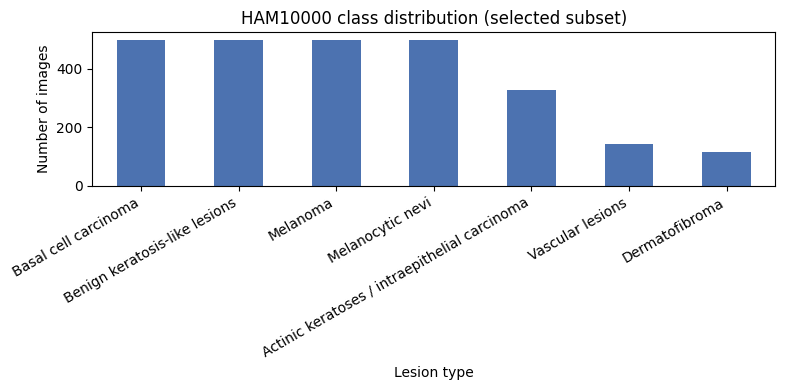

In [19]:
import matplotlib.pyplot as plt
dist = ham_index.meta["label_name"].value_counts()
plt.figure(figsize=(8, 4))
dist.plot(kind="bar", color="#4C72B0")
plt.title("HAM10000 class distribution (selected subset)")
plt.ylabel("Number of images")
plt.xlabel("Lesion type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(lab2_cfg.output_dir, "ham10000_class_distribution.png"), dpi=150)
plt.show()

## 6. Image filters (Average, Gaussian, Median, Sharpening, Sobel)

Each filter is implemented with OpenCV and wrapped as a torchvision-style
transform, so it slots into the same preprocessing pipeline used for the
"No Filter" baseline — only the filter step changes; resize, augmentation,
normalization, splits and training procedure stay identical across the 6
conditions per model.

In [20]:
class FilterBank:
    # Spatial-domain filters used for the Lab 2 comparison. Each method
    # takes and returns an RGB uint8 numpy array.

    @staticmethod
    def none(img):
        return img

    @staticmethod
    def average(img, ksize=5):
        return cv2.blur(img, (ksize, ksize))

    @staticmethod
    def gaussian(img, ksize=5, sigma=0):
        return cv2.GaussianBlur(img, (ksize, ksize), sigma)

    @staticmethod
    def median(img, ksize=5):
        return cv2.medianBlur(img, ksize)

    @staticmethod
    def sharpen(img):
        # Classic Laplacian-based sharpening kernel
        kernel = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]])
        return cv2.filter2D(img, -1, kernel)

    @staticmethod
    def sobel(img):
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        mag = cv2.magnitude(gx, gy)
        mag = np.clip(mag / (mag.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
        return cv2.cvtColor(mag, cv2.COLOR_GRAY2RGB)

    @classmethod
    def apply(cls, name, img):
        if name == "none":
            return cls.none(img)
        elif name == "average":
            return cls.average(img)
        elif name == "gaussian":
            return cls.gaussian(img)
        elif name == "median":
            return cls.median(img)
        elif name == "sharpen":
            return cls.sharpen(img)
        elif name == "sobel":
            return cls.sobel(img)
        raise ValueError(f"Unknown filter: {name}")


class FilterTransform:
    # Applies one FilterBank filter to a PIL image; slots in right after
    # Resize and before ToTensor/Normalize in the torchvision pipeline.

    def __init__(self, filter_name):
        self.filter_name = filter_name

    def __call__(self, pil_img):
        arr = np.array(pil_img.convert("RGB"))
        out = FilterBank.apply(self.filter_name, arr)
        return Image.fromarray(out.astype(np.uint8))

## 7. Visualize original vs. filtered examples

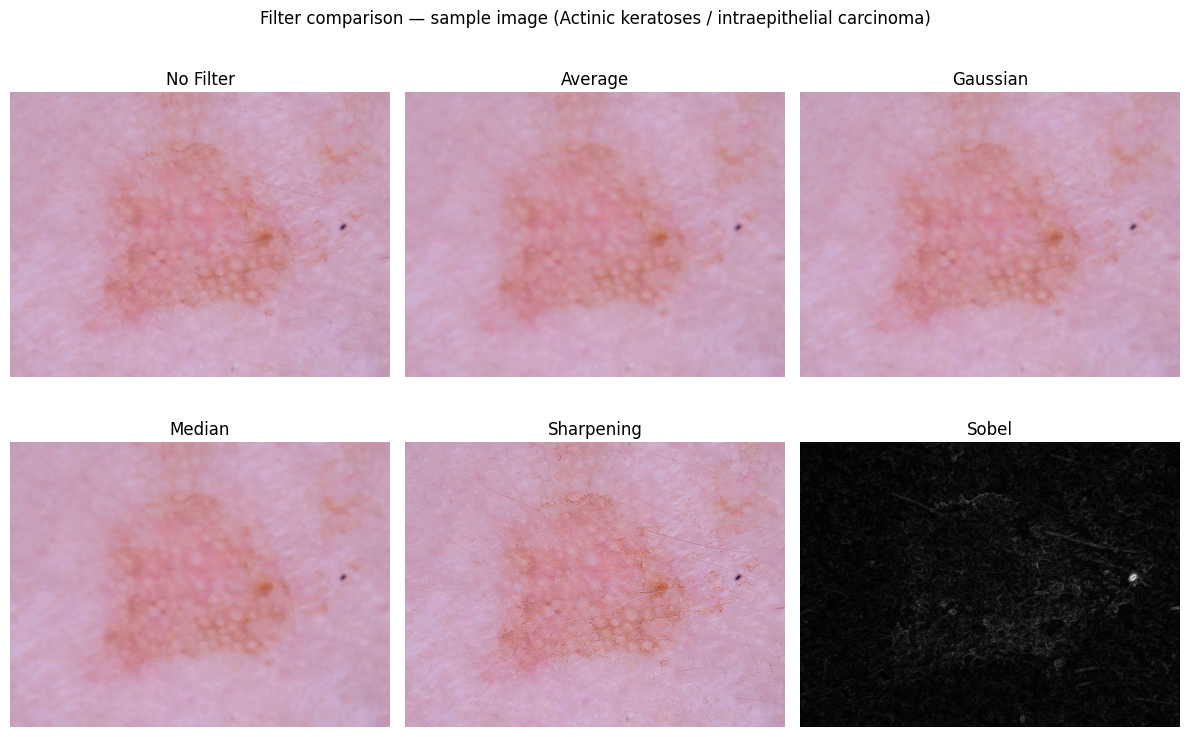

In [21]:
sample_path = ham_index.meta["path"].iloc[0]
sample_label = ham_index.meta["label_name"].iloc[0]
sample_img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, name in zip(axes.flat, lab2_cfg.filters):
    filtered = FilterTransform(name)(sample_img)
    ax.imshow(filtered)
    ax.set_title(lab2_cfg.filter_display_names[name])
    ax.axis("off")
plt.suptitle(f"Filter comparison — sample image ({sample_label})")
plt.tight_layout()
plt.savefig(os.path.join(lab2_cfg.output_dir, "filter_examples.png"), dpi=150)
plt.show()

## 8. Lab 2 dataset — train/val/test split, filter inserted into the transform pipeline

Same stratified-split logic as Lab 1's `SkinLesionData`, adapted to
HAM10000's flat (path, label) samples list, with a train/val/test split
carved out here (HAM10000 has no ready-made Train/Test folders). A fresh
`HAM2Data` is built per experimental condition — the split indices are
identical across filters (same seed, same input list), only the filter step
changes.

In [22]:
class HAM2Dataset(Dataset):
    # Same idea as Lab 1's FilteredImageDataset, over HAM10000 samples.

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = default_loader(path)
        if self.transform:
            image = self.transform(image)
        return image, label


class HAM2Data:
    # Builds the train/val/test DataLoaders for one filter condition.

    def __init__(self, cfg, samples, filter_name):
        self.cfg = cfg
        self.filter_name = filter_name
        self.samples = samples
        self.train_ds = self.val_ds = self.test_ds = None
        self.train_loader = self.val_loader = self.test_loader = None

    @staticmethod
    def _split(samples, cfg):
        labels = np.array([lbl for _, lbl in samples])
        idx = np.arange(len(samples))
        train_idx, temp_idx = train_test_split(
            idx, test_size=cfg.val_fraction + cfg.test_fraction,
            stratify=labels, random_state=cfg.random_seed,
        )
        temp_labels = labels[temp_idx]
        val_ratio_of_temp = cfg.val_fraction / (cfg.val_fraction + cfg.test_fraction)
        val_idx, test_idx = train_test_split(
            temp_idx, test_size=1 - val_ratio_of_temp,
            stratify=temp_labels, random_state=cfg.random_seed,
        )
        return train_idx, val_idx, test_idx

    def _get_transforms(self, train):
        normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        filter_step = FilterTransform(self.filter_name)
        if train:
            return T.Compose([
                T.Resize((self.cfg.image_size, self.cfg.image_size)),
                filter_step,
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
                T.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=0.2),
                T.RandomResizedCrop(self.cfg.image_size, scale=(0.8, 1.0)),
                T.ToTensor(),
                normalize,
            ])
        return T.Compose([
            T.Resize((self.cfg.image_size, self.cfg.image_size)),
            filter_step,
            T.ToTensor(),
            normalize,
        ])

    def load(self):
        cfg = self.cfg
        train_idx, val_idx, test_idx = self._split(self.samples, cfg)
        train_samples = [self.samples[i] for i in train_idx]
        val_samples = [self.samples[i] for i in val_idx]
        test_samples = [self.samples[i] for i in test_idx]

        self.train_ds = HAM2Dataset(train_samples, self._get_transforms(train=True))
        self.val_ds = HAM2Dataset(val_samples, self._get_transforms(train=False))
        self.test_ds = HAM2Dataset(test_samples, self._get_transforms(train=False))

        self.train_loader = DataLoader(self.train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
        self.val_loader = DataLoader(self.val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
        self.test_loader = DataLoader(self.test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
        return self


HAM_SAMPLES = ham_index.samples()
print(f"Total samples available for splitting: {len(HAM_SAMPLES)}")

Total samples available for splitting: 2584


## 9. Extended trainer — confusion matrix, curves, per-class metrics, macro-F1, balanced accuracy, ROC/AUC

Same two-stage (warm-up → fine-tune) procedure as Lab 1's `ModelTrainer`,
extended to also return everything Task 02's "Additional Analysis" section
asks for.

In [23]:
class FilterExperimentTrainer:
    # Runs one (model, filter) training/evaluation condition and returns
    # every metric/artifact needed for the Lab 2 comparison table and plots.

    def __init__(self, cfg, device):
        self.cfg = cfg
        self.device = device

    def _run_epoch(self, model, loader, criterion, optimizer=None):
        is_train = optimizer is not None
        model.train() if is_train else model.eval()
        total_loss, total_correct, total_samples = 0.0, 0, 0
        with torch.set_grad_enabled(is_train):
            for images, labels in loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                if is_train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * images.size(0)
                total_correct += (outputs.argmax(1) == labels).sum().item()
                total_samples += images.size(0)
        return total_loss / total_samples, total_correct / total_samples

    def evaluate(self, model, loader, num_classes):
        model.eval()
        all_labels, all_preds, all_probs = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                all_labels.extend(labels.numpy())
                all_preds.extend(probs.argmax(axis=1))
                all_probs.extend(probs)
        y_true, y_pred, y_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)

        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        balanced_acc = balanced_accuracy_score(y_true, y_pred)
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class="ovr", average="weighted")
        except ValueError:
            auc = float("nan")

        return {
            "metrics": {
                "Accuracy (%)": round(acc * 100, 2),
                "Precision (%)": round(precision * 100, 2),
                "Recall (%)": round(recall * 100, 2),
                "F1-score (%)": round(f1 * 100, 2),
                "Macro-F1 (%)": round(macro_f1 * 100, 2),
                "Balanced Accuracy (%)": round(balanced_acc * 100, 2),
                "AUC (%)": round(auc * 100, 2),
            },
            "confusion_matrix": confusion_matrix(y_true, y_pred, labels=list(range(num_classes))),
            "classification_report": classification_report(
                y_true, y_pred, labels=list(range(num_classes)),
                target_names=[str(i) for i in range(num_classes)],
                output_dict=True, zero_division=0,
            ),
            "y_true": y_true, "y_pred": y_pred, "y_probs": y_probs,
        }

    def run(self, model_name, filter_name, data, num_classes):
        cfg = self.cfg
        print(f"\n=== Training {model_name} | filter = {filter_name} ===")
        model = ModelFactory.build(model_name, num_classes).to(self.device)
        criterion = nn.CrossEntropyLoss()
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        # Stage 1: feature-extraction warm-up (freeze backbone, train head only)
        ModelFactory.set_backbone_trainable(model, trainable=False)
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.learning_rate)
        for epoch in range(cfg.feature_extract_epochs):
            tl, ta = self._run_epoch(model, data.train_loader, criterion, optimizer)
            vl, va = self._run_epoch(model, data.val_loader, criterion, optimizer=None)
            history["train_loss"].append(tl); history["val_loss"].append(vl)
            history["train_acc"].append(ta); history["val_acc"].append(va)
            print(f"  [warmup {epoch+1}/{cfg.feature_extract_epochs}] train_acc={ta:.3f} val_acc={va:.3f}")

        # Stage 2: full fine-tune
        ModelFactory.set_backbone_trainable(model, trainable=True)
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1 ** 0.5, patience=7, min_lr=0.5e-6
        )
        best_val_acc, best_state = 0.0, copy.deepcopy(model.state_dict())
        for epoch in range(cfg.fine_tune_epochs):
            tl, ta = self._run_epoch(model, data.train_loader, criterion, optimizer)
            vl, va = self._run_epoch(model, data.val_loader, criterion, optimizer=None)
            scheduler.step(vl)
            history["train_loss"].append(tl); history["val_loss"].append(vl)
            history["train_acc"].append(ta); history["val_acc"].append(va)
            if va > best_val_acc:
                best_val_acc, best_state = va, copy.deepcopy(model.state_dict())
            print(f"  [finetune {epoch+1}/{cfg.fine_tune_epochs}] train_acc={ta:.3f} val_acc={va:.3f}")

        model.load_state_dict(best_state)
        eval_result = self.evaluate(model, data.test_loader, num_classes)
        torch.save(model.state_dict(), cfg.checkpoint_path(model_name, filter_name))

        return {"model": model_name, "filter": filter_name, "history": history, **eval_result}

## 10. Run all experiments — 3 models × (baseline + 5 filters) = 18 runs

For each of the 3 best models, one `HAM2Data` is built per filter (identical
split indices reused for every filter — only pixels change), then
trained/evaluated. Results are appended to a CSV after every run so a Colab
timeout doesn't lose completed runs.

In [24]:
filter_trainer = FilterExperimentTrainer(lab2_cfg, LAB2_DEVICE)
lab2_raw_results = []   # full dict per run (history, confusion matrix, y_probs, ...)
lab2_table_rows = []    # flat rows matching the Task 02 comparison table

RESULTS_CSV = os.path.join(lab2_cfg.output_dir, "table_lab2_filtering_results.csv")

for model_name in BEST_3_MODELS:
    for filter_name in lab2_cfg.filters:
        data_condition = HAM2Data(lab2_cfg, HAM_SAMPLES, filter_name).load()
        result = filter_trainer.run(model_name, filter_name, data_condition, len(ham_classes))
        lab2_raw_results.append(result)

        row = {
            "Model": model_name,
            "Filter": lab2_cfg.filter_display_names[filter_name],
            **result["metrics"],
        }
        lab2_table_rows.append(row)
        pd.DataFrame(lab2_table_rows).to_csv(RESULTS_CSV, index=False)

lab2_df = pd.DataFrame(lab2_table_rows)
lab2_df


=== Training resnet50 | filter = none ===
  [warmup 1/2] train_acc=0.263 val_acc=0.304
  [warmup 2/2] train_acc=0.378 val_acc=0.384
  [finetune 1/6] train_acc=0.524 val_acc=0.634
  [finetune 2/6] train_acc=0.695 val_acc=0.680
  [finetune 3/6] train_acc=0.783 val_acc=0.704
  [finetune 4/6] train_acc=0.830 val_acc=0.701
  [finetune 5/6] train_acc=0.868 val_acc=0.706
  [finetune 6/6] train_acc=0.887 val_acc=0.698

=== Training resnet50 | filter = average ===
  [warmup 1/2] train_acc=0.221 val_acc=0.314
  [warmup 2/2] train_acc=0.357 val_acc=0.402
  [finetune 1/6] train_acc=0.515 val_acc=0.652
  [finetune 2/6] train_acc=0.662 val_acc=0.673
  [finetune 3/6] train_acc=0.747 val_acc=0.683
  [finetune 4/6] train_acc=0.790 val_acc=0.701
  [finetune 5/6] train_acc=0.834 val_acc=0.732
  [finetune 6/6] train_acc=0.857 val_acc=0.711

=== Training resnet50 | filter = gaussian ===
  [warmup 1/2] train_acc=0.266 val_acc=0.389
  [warmup 2/2] train_acc=0.376 val_acc=0.443
  [finetune 1/6] train_acc=0.5

,Model,Filter,Accuracy (%),Precision (%),Recall (%),F1-score (%),Macro-F1 (%),Balanced Accuracy (%),AUC (%)
0,resnet50,No Filter,74.48,75.32,74.48,74.52,73.52,71.45,95.56
1,resnet50,Average,69.33,70.64,69.33,69.51,70.35,69.26,93.35
2,resnet50,Gaussian,72.68,74.17,72.68,72.93,73.31,72.03,93.52
3,resnet50,Median,68.81,71.97,68.81,68.75,70.31,69.57,91.81
4,resnet50,Sharpening,70.36,74.51,70.36,70.06,69.24,66.77,94.40
5,resnet50,Sobel,44.07,51.24,44.07,40.70,37.23,38.46,79.36
6,resnet101,No Filter,72.94,75.13,72.94,73.10,72.82,70.60,94.92
7,resnet101,Average,70.62,71.02,70.62,70.62,71.91,71.27,93.96
8,resnet101,Gaussian,76.80,77.93,76.80,76.87,77.23,74.85,95.52
9,resnet101,Median,74.23,74.85,74.23,74.29,75.70,74.76,95.16


## 11. Training curves for every run

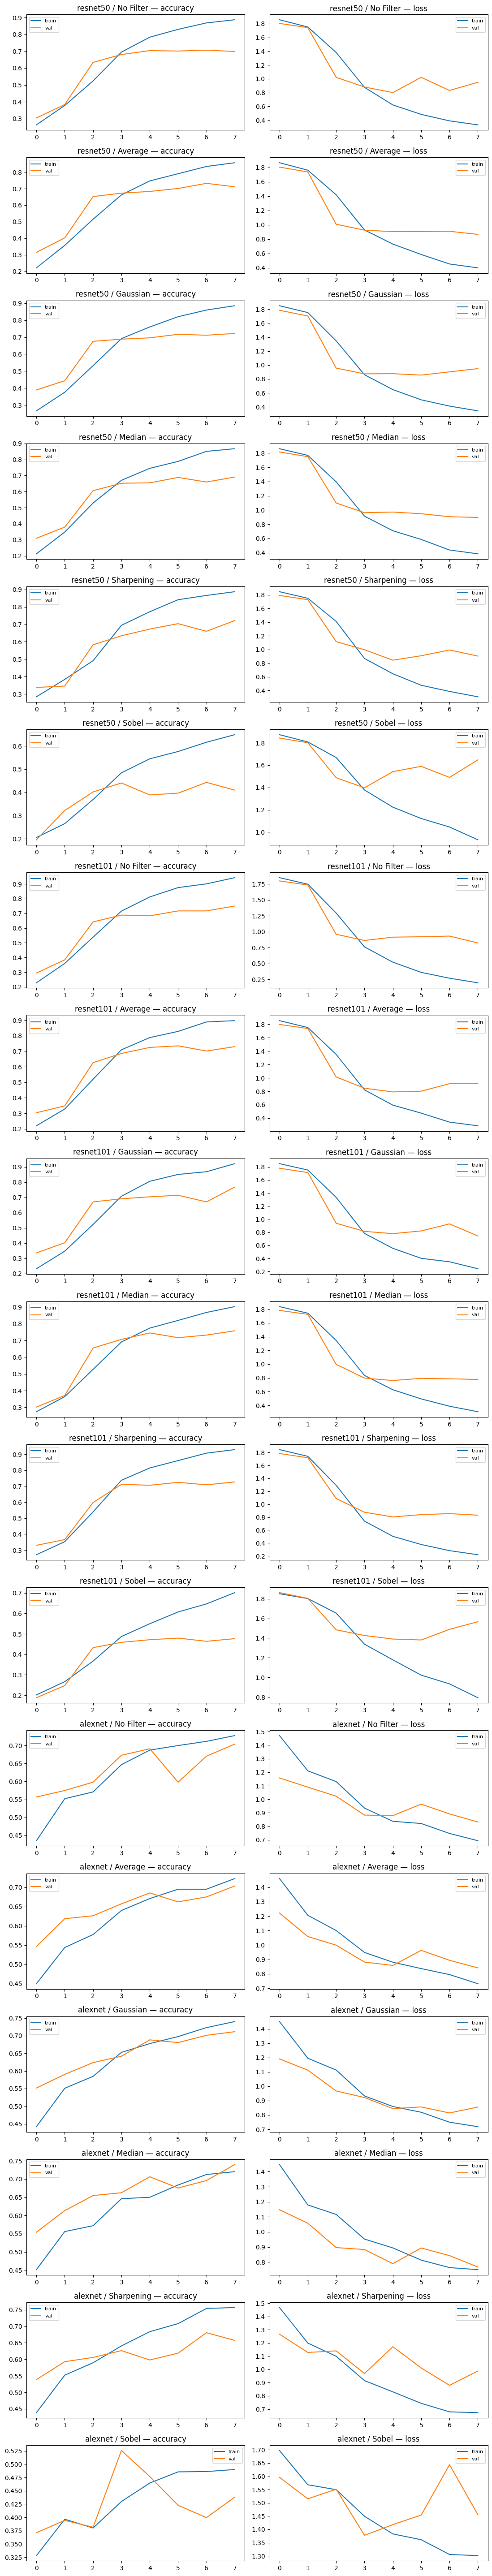

In [25]:
n_runs = len(lab2_raw_results)
fig, axes = plt.subplots(n_runs, 2, figsize=(11, 3.2 * n_runs))
for i, result in enumerate(lab2_raw_results):
    h = result["history"]
    label = f"{result['model']} / {lab2_cfg.filter_display_names[result['filter']]}"

    axes[i, 0].plot(h["train_acc"], label="train")
    axes[i, 0].plot(h["val_acc"], label="val")
    axes[i, 0].set_title(f"{label} — accuracy")
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].plot(h["train_loss"], label="train")
    axes[i, 1].plot(h["val_loss"], label="val")
    axes[i, 1].set_title(f"{label} — loss")
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(lab2_cfg.output_dir, "training_curves.png"), dpi=150)
plt.show()

## 12. Confusion matrix for every run

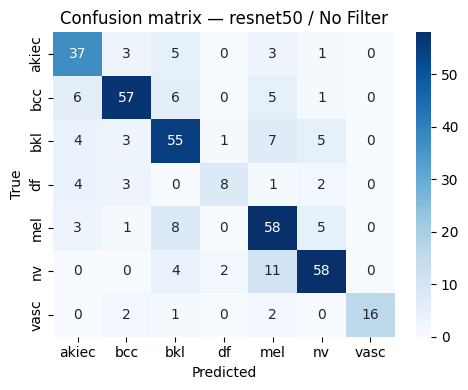

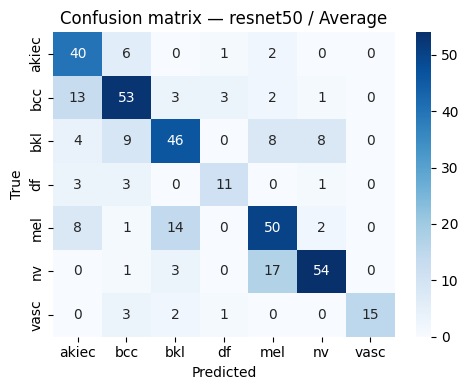

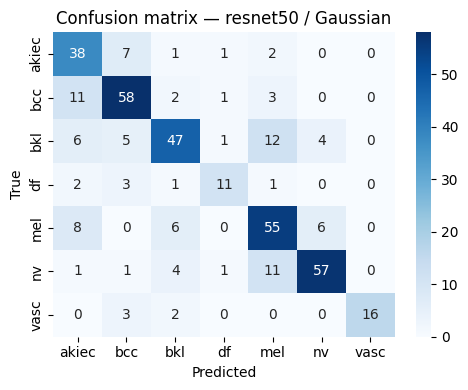

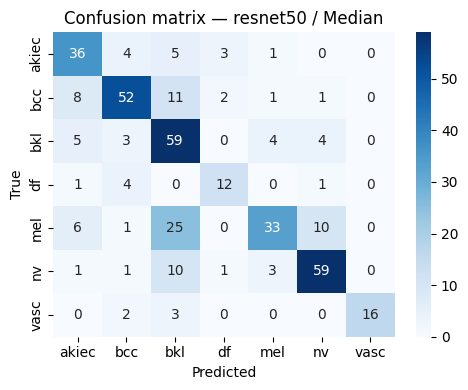

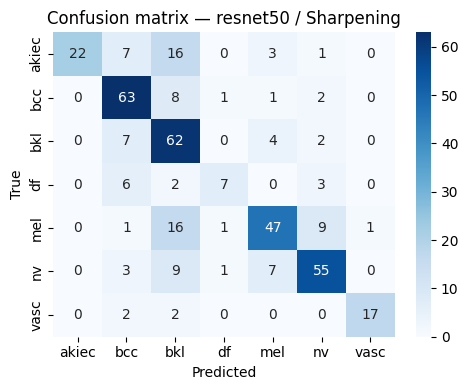

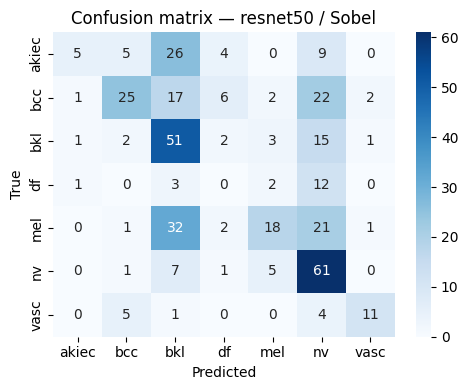

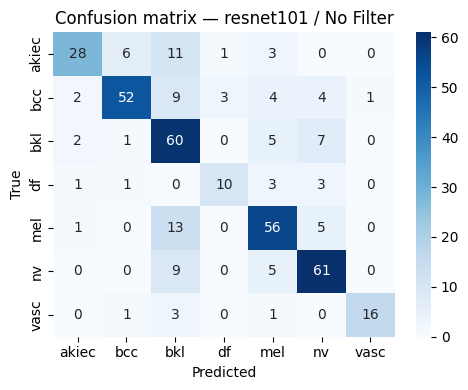

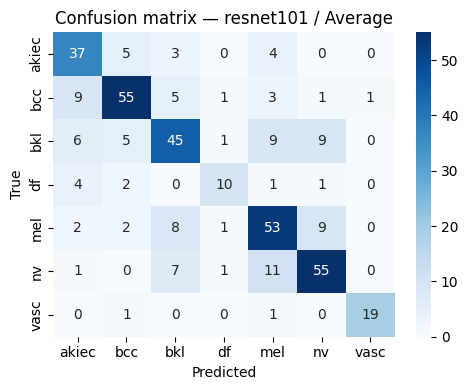

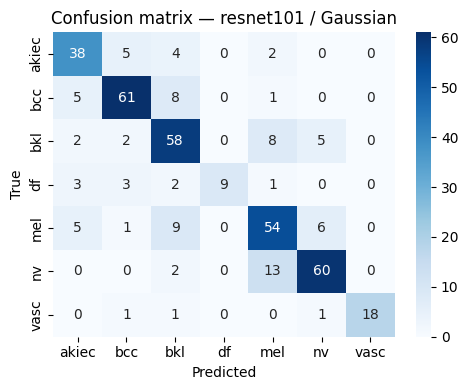

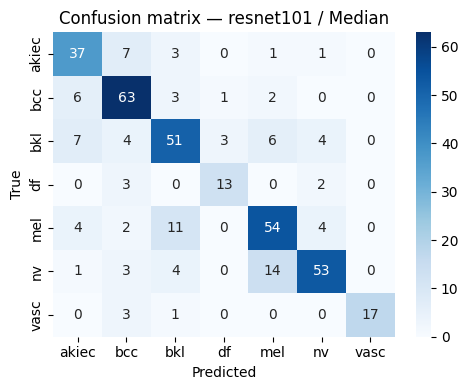

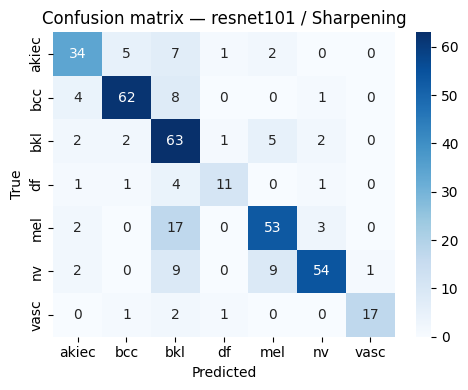

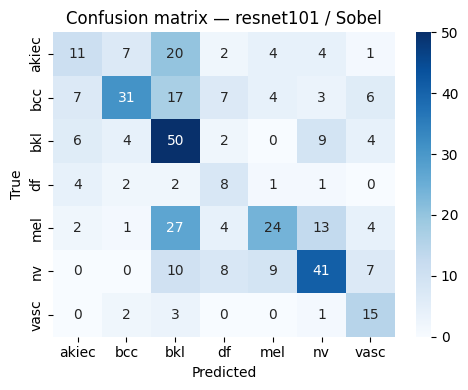

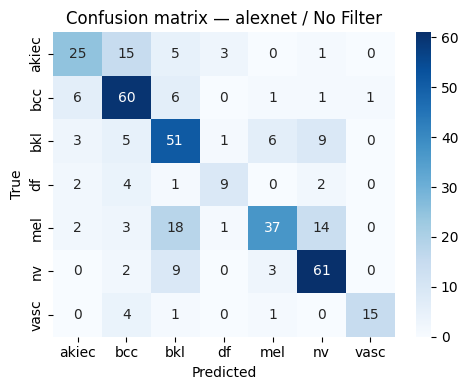

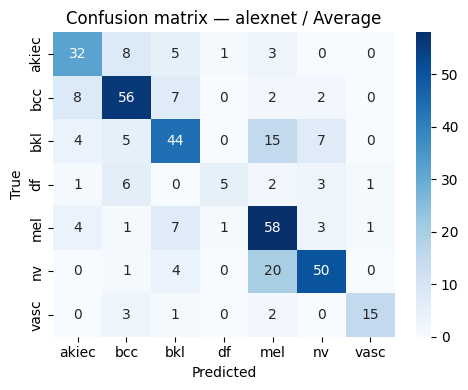

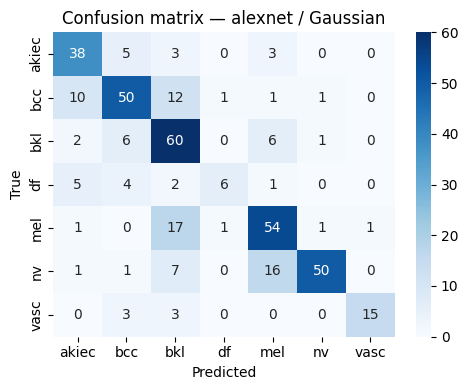

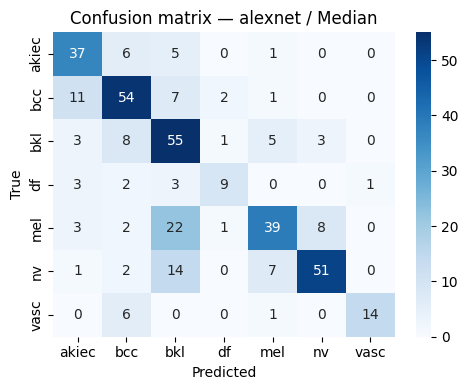

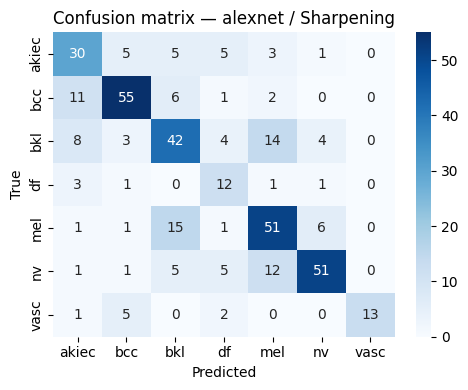

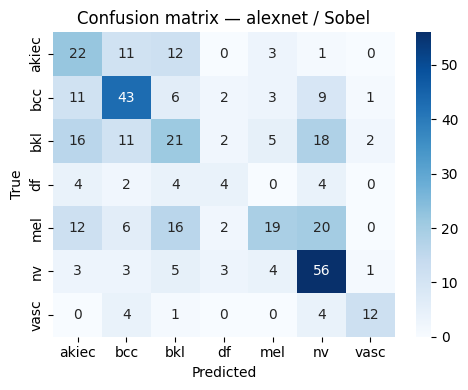

In [26]:
for result in lab2_raw_results:
    cm = result["confusion_matrix"]
    label = f"{result['model']} / {lab2_cfg.filter_display_names[result['filter']]}"
    plt.figure(figsize=(5, 4))
    if HAS_SEABORN:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=ham_classes, yticklabels=ham_classes)
    else:
        plt.imshow(cm, cmap="Blues")
        plt.colorbar()
        plt.xticks(range(len(ham_classes)), ham_classes, rotation=45)
        plt.yticks(range(len(ham_classes)), ham_classes)
    plt.title(f"Confusion matrix — {label}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    safe_name = f"cm_{result['model']}_{result['filter']}.png"
    plt.savefig(os.path.join(lab2_cfg.output_dir, safe_name), dpi=150)
    plt.show()

## 13. Per-class precision / recall / F1 for every run

In [27]:
per_class_rows = []
for result in lab2_raw_results:
    report = result["classification_report"]
    for cls_idx_str, scores in report.items():
        if cls_idx_str in ("accuracy", "macro avg", "weighted avg"):
            continue
        cls_name = ham_classes[int(cls_idx_str)]
        per_class_rows.append({
            "Model": result["model"],
            "Filter": lab2_cfg.filter_display_names[result["filter"]],
            "Class": cls_name,
            "Precision": round(scores["precision"], 3),
            "Recall": round(scores["recall"], 3),
            "F1-score": round(scores["f1-score"], 3),
            "Support": int(scores["support"]),
        })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(os.path.join(lab2_cfg.output_dir, "per_class_metrics.csv"), index=False)
per_class_df

,Model,Filter,Class,Precision,Recall,F1-score,Support
0,resnet50,No Filter,akiec,0.685,0.755,0.718,49
1,resnet50,No Filter,bcc,0.826,0.760,0.792,75
2,resnet50,No Filter,bkl,0.696,0.733,0.714,75
3,resnet50,No Filter,df,0.727,0.444,0.552,18
4,resnet50,No Filter,mel,0.667,0.773,0.716,75
...,...,...,...,...,...,...,...
121,alexnet,Sobel,bkl,0.323,0.280,0.300,75
122,alexnet,Sobel,df,0.308,0.222,0.258,18
123,alexnet,Sobel,mel,0.559,0.253,0.349,75
124,alexnet,Sobel,nv,0.500,0.747,0.599,75


## 14. ROC curves (one-vs-rest) — every filter, per model

Melanoma (`mel`) is the clinically critical class, so it's used as the
positive class for the ROC comparison (falls back to the first available
class if `mel` isn't in the selected subset).

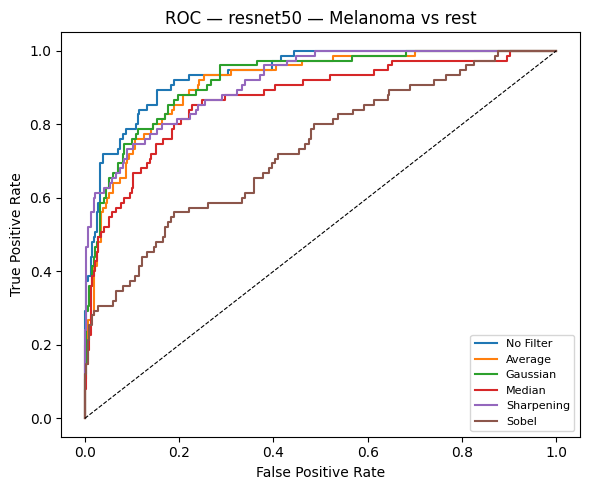

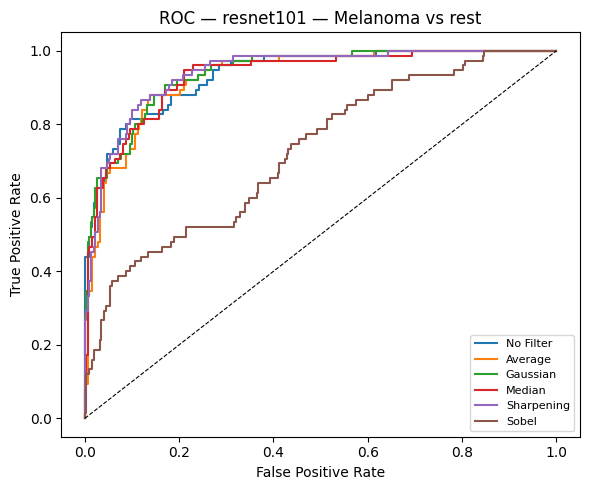

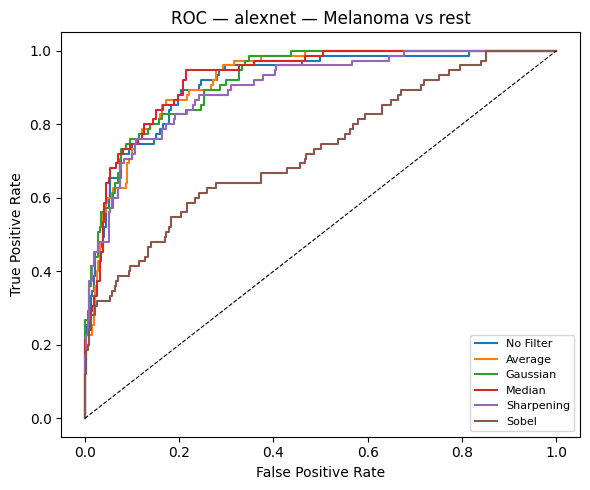

In [28]:
TARGET_CLASS_FOR_ROC = "mel" if "mel" in ham_classes else ham_classes[0]
target_idx = ham_classes.index(TARGET_CLASS_FOR_ROC)

for model_name in BEST_3_MODELS:
    plt.figure(figsize=(6, 5))
    for result in lab2_raw_results:
        if result["model"] != model_name:
            continue
        y_true_bin = label_binarize(result["y_true"], classes=list(range(len(ham_classes))))[:, target_idx]
        y_score = result["y_probs"][:, target_idx]
        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        plt.plot(fpr, tpr, label=lab2_cfg.filter_display_names[result["filter"]])
    plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    plt.title(f"ROC — {model_name} — {LESION_TYPE_DICT.get(TARGET_CLASS_FOR_ROC, TARGET_CLASS_FOR_ROC)} vs rest")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(lab2_cfg.output_dir, f"roc_{model_name}.png"), dpi=150)
    plt.show()

In [29]:
display(lab2_df)

,Model,Filter,Accuracy (%),Precision (%),Recall (%),F1-score (%),Macro-F1 (%),Balanced Accuracy (%),AUC (%)
0,resnet50,No Filter,74.48,75.32,74.48,74.52,73.52,71.45,95.56
1,resnet50,Average,69.33,70.64,69.33,69.51,70.35,69.26,93.35
2,resnet50,Gaussian,72.68,74.17,72.68,72.93,73.31,72.03,93.52
3,resnet50,Median,68.81,71.97,68.81,68.75,70.31,69.57,91.81
4,resnet50,Sharpening,70.36,74.51,70.36,70.06,69.24,66.77,94.40
5,resnet50,Sobel,44.07,51.24,44.07,40.70,37.23,38.46,79.36
6,resnet101,No Filter,72.94,75.13,72.94,73.10,72.82,70.60,94.92
7,resnet101,Average,70.62,71.02,70.62,70.62,71.91,71.27,93.96
8,resnet101,Gaussian,76.80,77.93,76.80,76.87,77.23,74.85,95.52
9,resnet101,Median,74.23,74.85,74.23,74.29,75.70,74.76,95.16


## 15. Comparative analysis — effect of each filter relative to the unfiltered baseline

In [30]:
baseline_name = lab2_cfg.filter_display_names["none"]
filter_order = [lab2_cfg.filter_display_names[f] for f in lab2_cfg.filters]

pivot_macro_f1 = lab2_df.pivot(index="Filter", columns="Model", values="Macro-F1 (%)").reindex(filter_order)
delta_vs_baseline = pivot_macro_f1.subtract(pivot_macro_f1.loc[baseline_name], axis=1)

print("Change in Macro-F1 (%) vs. the unfiltered baseline (positive = filter helped):")
delta_vs_baseline.drop(index=baseline_name)

Change in Macro-F1 (%) vs. the unfiltered baseline (positive = filter helped):


Model,alexnet,resnet101,resnet50
Filter,,,
Average,-1.10,-0.91,-3.17
Gaussian,2.87,4.41,-0.21
Median,1.10,2.88,-3.21
Sharpening,-1.14,3.51,-4.28
Sobel,-22.03,-28.70,-36.29


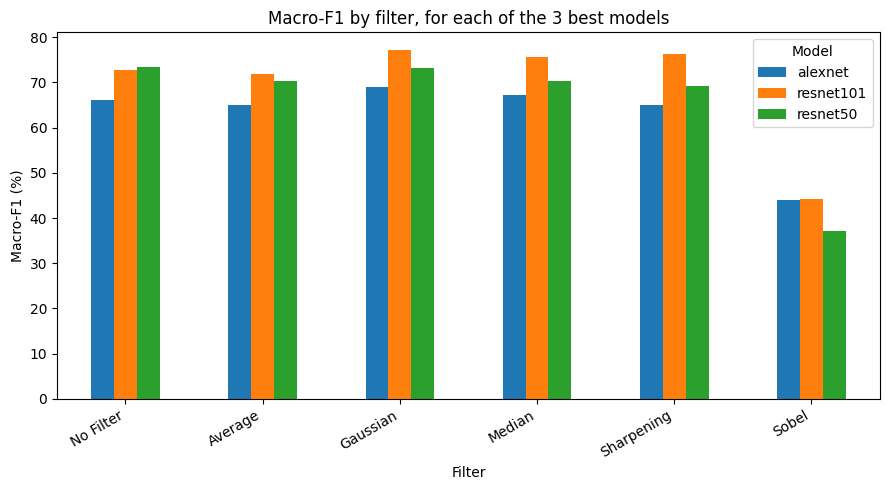

In [31]:
ax = pivot_macro_f1.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Macro-F1 (%)")
ax.set_title("Macro-F1 by filter, for each of the 3 best models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(lab2_cfg.output_dir, "macro_f1_by_filter.png"), dpi=150)
plt.show()

In [32]:
# Which filter causes the biggest swing (up or down) for each model?
biggest_change_rows = []
for model_name in BEST_3_MODELS:
    non_baseline = lab2_df[(lab2_df["Model"] == model_name) & (lab2_df["Filter"] != baseline_name)].copy()
    base_row = lab2_df[(lab2_df["Model"] == model_name) & (lab2_df["Filter"] == baseline_name)].iloc[0]
    non_baseline["Abs Macro-F1 Change"] = (non_baseline["Macro-F1 (%)"] - base_row["Macro-F1 (%)"]).abs()
    worst = non_baseline.sort_values("Abs Macro-F1 Change", ascending=False).iloc[0]
    biggest_change_rows.append({
        "Model": model_name,
        "Filter with largest change": worst["Filter"],
        "|Δ Macro-F1| (%)": round(worst["Abs Macro-F1 Change"], 2),
        "Macro-F1 improved?": bool(worst["Macro-F1 (%)"] > base_row["Macro-F1 (%)"]),
    })

biggest_change_df = pd.DataFrame(biggest_change_rows)
biggest_change_df

,Model,Filter with largest change,|Δ Macro-F1| (%),Macro-F1 improved?
0,resnet50,Sobel,36.29,False
1,resnet101,Sobel,28.70,False
2,alexnet,Sobel,22.03,False


## 16. Discussion — answers to the Task 02 questions

**1) Which three pretrained models performed best in Lab Activity 1?**
Printed programmatically above (`BEST_3_MODELS`), read straight out of
Lab 1's `table1_df` so it always matches whatever Lab 1 actually produced —
fill the blanks on the task sheet with those three names.

**2) How does filtering affect each of the three models?**
Read the `lab2_df` table above: for each model, compare its "No Filter" row
against its five filtered rows across Accuracy / Precision / Recall /
F1-score / Macro-F1 / Balanced Accuracy / AUC.

**3) Which filter produces the greatest change compared with the unfiltered
baseline?** — see `biggest_change_df` above (computed per model directly
from the run results).

**4) Does the effect of a filter remain consistent across all three
models?** Compare the "Filter with largest change" column in
`biggest_change_df`: if the same filter tops the list for all three models,
the effect is consistent; if it differs, filtering interacts with model
architecture — e.g. a model that leans more on fine texture may be hurt more
by smoothing than one with more redundant channels/skip connections.

**5) Does filtering improve or decrease macro-F1 and balanced accuracy?**
Read the "Macro-F1 improved?" column of `biggest_change_df`, and the sign of
`delta_vs_baseline` / the `Balanced Accuracy (%)` column of `lab2_df`.

**6) Which lesion classes are most affected by filtering?** Group
`per_class_df` by `Class` and compare F1-score across filters (same model);
the classes with the largest spread are the most filter-sensitive — this is
usually visible directly in the confusion matrices above (which classes
gain/lose the most off-diagonal mass as the filter changes).

**7) Why might smoothing remove useful lesion texture or morphological
information?** Average, Gaussian and Median filters are low-pass: they
average neighbouring pixel intensities, suppressing high-frequency content.
In dermoscopic images, high-frequency content is exactly where diagnostic
cues live — the fine reticular pigment network of a nevus, irregular
pigment network or blue-white veil of a melanoma, granular texture that
separates benign keratoses from malignant lesions. Blurring this away makes
classes look more alike and pushes the model toward relying on coarse
shape/colour alone.

**8) Why might sharpening or edge detection help or hurt classification?**
Sharpening (unsharp-masking-style) amplifies high-frequency edges, which can
make border irregularity and pigment-network boundaries more prominent —
potentially *helping* when the deciding feature is edge structure. It also
amplifies sensor noise and hair/artifact edges common in dermoscopy, which
can *hurt* if the network keys off spurious high-frequency artifacts
instead. Sobel goes further and discards all colour/intensity information,
keeping only gradient magnitude — useful if lesion border/shape alone is
discriminative, but often harmful here specifically because colour
(blue-white veil, red-brown pigmentation) is one of the strongest
diagnostic signals in HAM10000-style dermoscopy, and Sobel destroys it
entirely.

**9) What is the difference between convolution and correlation?** Both
slide a kernel over the image and compute a weighted sum, but *convolution*
flips the kernel 180° (both axes) before sliding it, while *cross-
correlation* uses the kernel as-is. For a symmetric kernel (mean, Gaussian,
the sharpening kernel used above) the flip has no effect, so the two give
identical output. For an asymmetric kernel — such as a Sobel kernel — they
are genuinely different operations; frameworks like OpenCV's `filter2D` and
PyTorch's `Conv2d` actually implement cross-correlation internally (no
kernel flip) even though the operation is conventionally still called
"convolution."

**10) Relationship between classical image processing and deep-learning-
based feature extraction.** A classical filter (mean, Gaussian, Sobel, ...)
is a single, hand-designed, fixed convolution kernel chosen because it is
known to enhance or suppress one specific image property (blur, edges,
noise). A CNN's convolutional layers perform the *same* mathematical
operation — kernels convolved/correlated over the input — but the weights
are *learned* from data rather than hand-specified, there are many of them
stacked across layers, and the earliest layers of a trained CNN often
converge to filters that resemble classical edge/blob detectors on their
own. Lab 2 essentially tests what happens when the input is preprocessed
with one *fixed* filter before the network learns its *own* filters on top
of that: if the fixed filter destroys information the network needs (e.g.
Sobel discarding colour), no amount of downstream learned filtering can
recover it — which is why classical preprocessing choices still matter even
inside an otherwise fully deep-learning pipeline.

## 17. Download Lab 2 results

In [ ]:
from google.colab import files

lab2_output_files = [
    "table_lab2_filtering_results.csv",
    "per_class_metrics.csv",
    "ham10000_class_distribution.png",
    "filter_examples.png",
    "training_curves.png",
    "macro_f1_by_filter.png",
]
for fname in lab2_output_files:
    fpath = os.path.join(lab2_cfg.output_dir, fname)
    if os.path.exists(fpath):
        files.download(fpath)

## 18. GitHub submission

Push the `Lab 02` folder (this notebook + `results_lab2/` outputs) to your
repository, together with a short `README.md` — a ready-to-use one is
provided as a separate file alongside this notebook.